In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hf://datasets/Idankhen/SmartFitnessNutritionAnalyticsDataset/Final_data .csv')





/Users/brankomitic/DataspellProjects/Diplomski_sam/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  str    
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  str    
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   20000 non-n

In [4]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [5]:
df_m = df[df['Gender'] == 'Male']
df_f=df[df['Gender'] == 'Female']

In [6]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
       'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins',
       'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method',
       'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets',
       'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle',
       'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg',
       'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin'],
      dtype='str')

In [7]:
df['Physical exercise'].value_counts().sort_index()

Physical exercise
-0.07      8
-0.06     37
-0.05    118
-0.04    361
-0.03    937
        ... 
 4.01    145
 4.02    101
 4.03     52
 4.04     23
 4.05      8
Name: count, Length: 67, dtype: int64

In [8]:
features = ["Age",
 "Weight (kg)",
"Height (m)",
"Avg_BPM",
"Resting_BPM",
"Session_Duration (hours)",
"Fat_Percentage",
"Workout_Frequency (days/week)",
"Experience_Level",
"Daily meals frequency",
"Carbs",
"Proteins",
"Fats",
"Sets",
"Reps"]

features = df[features]

<Axes: >

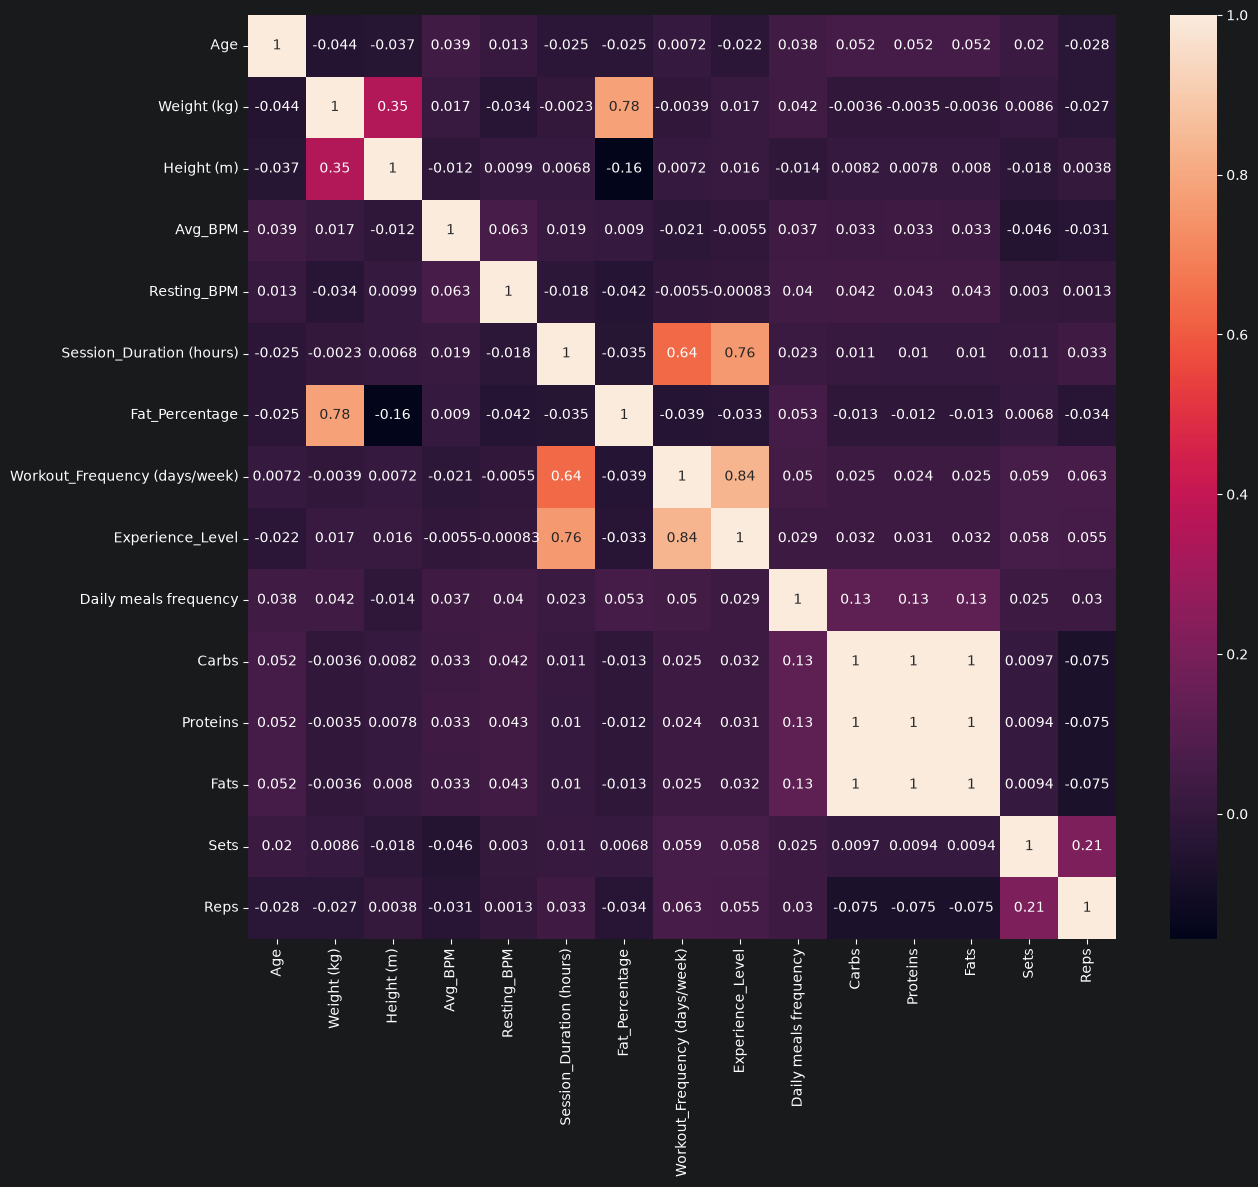

In [9]:
import seaborn as sb

corr = features.corr()

#print (corr)

plt.figure(figsize=(14,12))
sb.heatmap(corr, annot=True)



In [10]:
df['Carbs']

0        267.68
1        214.32
2        246.04
3        203.22
4        332.79
          ...  
19995    235.35
19996    149.77
19997    243.61
19998    240.16
19999    219.88
Name: Carbs, Length: 20000, dtype: float64

In [11]:
#corr.loc[["Carbs", "Proteins", "Fats"], ["Carbs", "Proteins", "Fats"]]
features.drop(columns=["Carbs", "Fats"], inplace=True)

<Axes: >

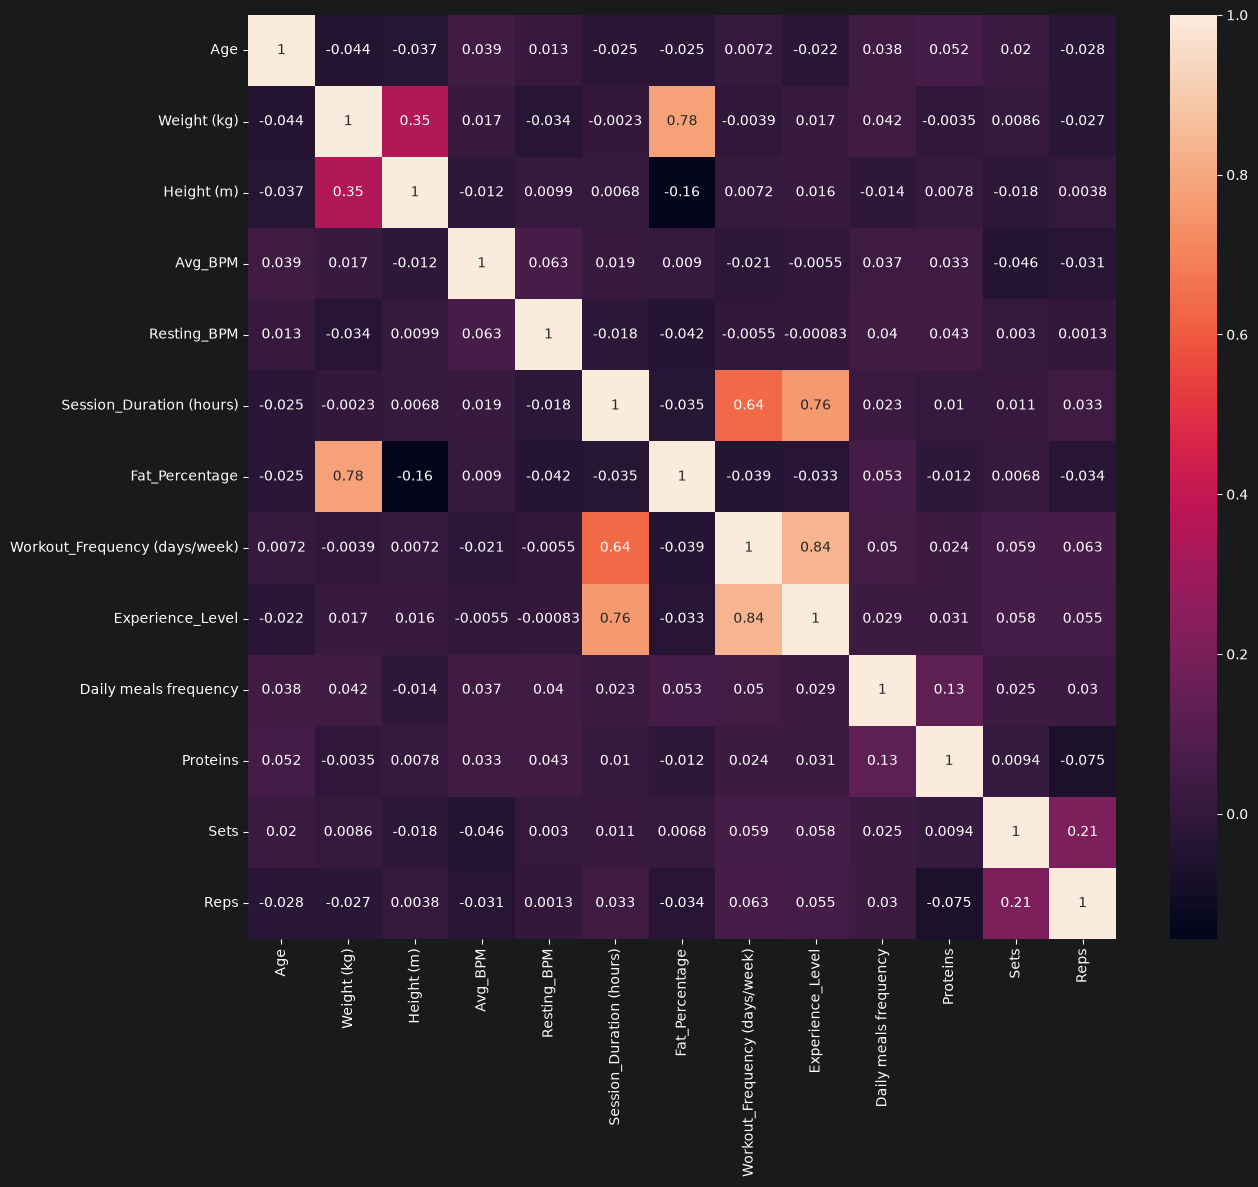

In [12]:

corr = features.corr()

#print (corr)

plt.figure(figsize=(14,12))
sb.heatmap(corr, annot=True)

In [13]:
df['Experience_Level'].value_counts()

Experience_Level
1.00    4944
2.00    2222
1.99    1788
2.01    1762
1.01    1629
3.00    1014
1.98     912
2.02     895
1.02     844
2.99     839
3.01     826
2.98     443
3.02     422
1.97     325
2.03     300
1.03     274
2.97     144
3.03     138
1.96      63
2.04      57
1.04      53
2.96      35
3.04      29
1.05      11
1.95       9
2.05       9
3.05       5
1.94       3
2.95       2
2.06       1
1.06       1
2.94       1
Name: count, dtype: int64

In [14]:
df['Reps'].round().value_counts().sort_index()

Reps
5.0       42
8.0       77
10.0     279
12.0     334
15.0    2378
16.0    1972
17.0    1811
18.0    1466
19.0    1525
20.0    1671
21.0    1750
22.0    1609
23.0    1659
24.0    1926
25.0    1486
30.0      15
Name: count, dtype: int64

In [15]:
type(features)

pandas.DataFrame

In [16]:
features.shape

(20000, 13)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled=scaler.fit_transform(features)



In [18]:
X_scaled.shape

(20000, 13)

[259999.99999999985,
 226920.34767702615,
 204464.38041878564,
 194463.062559622,
 189756.07570969325,
 182727.563375085,
 178131.7890449586,
 170371.75832035893,
 167121.81577712804,
 163914.47489765377]

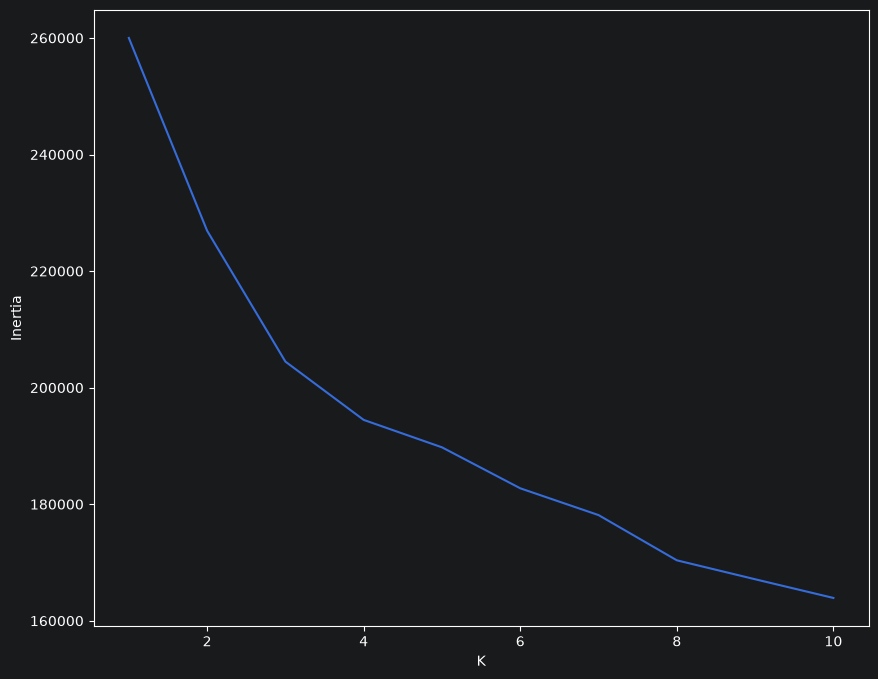

In [19]:
from sklearn.cluster import KMeans


inertia = []
for K in range(1,11):
 kmeans = KMeans(n_clusters=K, random_state=10)
 kmeans.fit(X_scaled)
 inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,8))
plt.plot(range(1,11),inertia)
plt.xlabel('K')
plt.ylabel('Inertia')

inertia


Vidimo iz grafikona da je elbow kod K=3 i K=4 pa ce nam to biti broj klastera za kmeans


[0.1181782756206643,
 0.1267631301931038,
 0.10828366157173314,
 0.09090585393394775,
 0.09407863099673738,
 0.08241153829117964,
 0.08984439183744912,
 0.0895605919238005,
 0.0886743859709745]

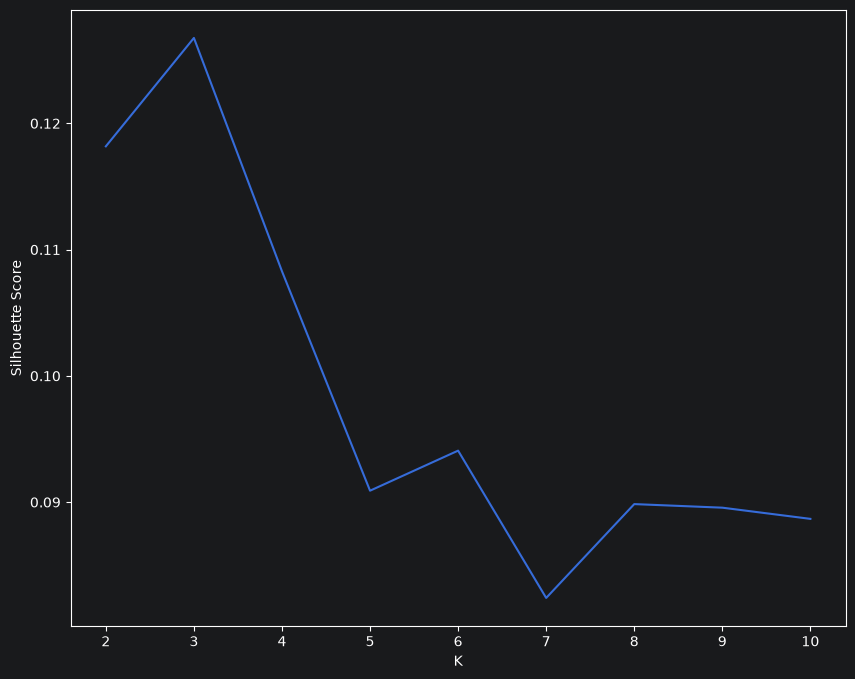

In [20]:
#silhouete score

from sklearn.metrics import silhouette_score

silhouette_scores = []
for K in range(2,11):
 kmeans = KMeans(n_clusters=K, random_state=10)
 kmeans.fit(X_scaled)
 silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(10,8))
plt.plot(range(2,11),silhouette_scores)

plt.xlabel('K')
plt.ylabel('Silhouette Score')

silhouette_scores



In [21]:
from scipy.stats.mstats import winsorize

features_winsorized = features.copy()

columns_to_winsorize = ['Weight (kg)','Proteins']

for col in columns_to_winsorize:
    features_winsorized[col] = winsorize(features_winsorized[col], limits=[0.01, 0.01])

scaler = StandardScaler()
X_scaled_winsorized = scaler.fit_transform(features_winsorized)


In [22]:
silhouette_scores_winsorized = []

for K in range(2, 11):
    kmeans = KMeans(n_clusters=K, random_state=10)
    kmeans.fit(X_scaled_winsorized)
    silhouette_scores_winsorized.append(
        silhouette_score(X_scaled_winsorized, kmeans.labels_)
    )

silhouette_scores_winsorized

[0.11815073633521797,
 0.12668043520206296,
 0.10568541719786408,
 0.10246024507794477,
 0.09629453185743866,
 0.08956044177314912,
 0.08576382118460388,
 0.08791984895685204,
 0.08817698700745552]

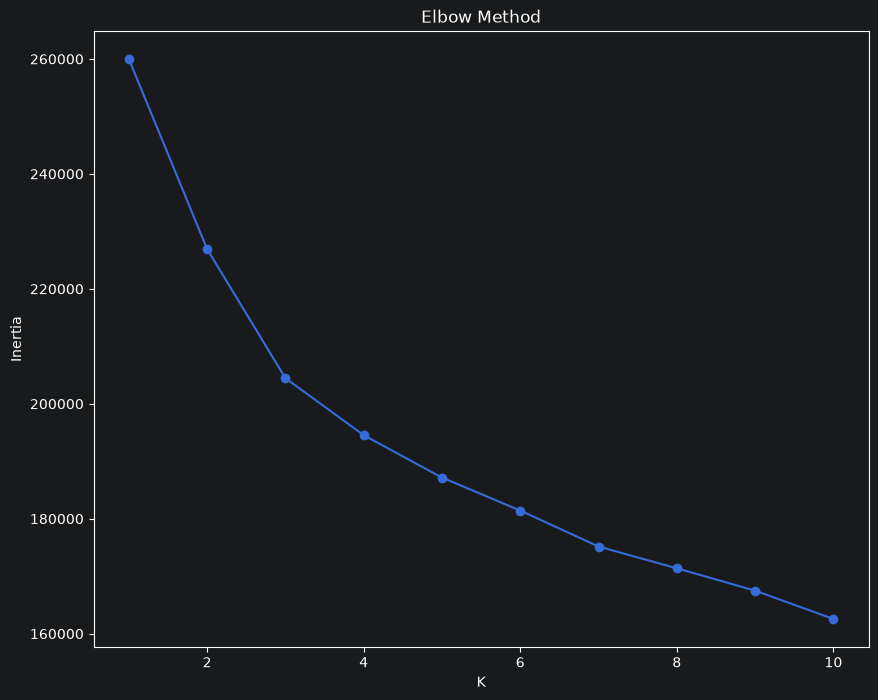

In [23]:
inertia_winsorized = []

for K in range(1, 11):
    kmeans = KMeans(n_clusters=K, random_state=10)
    kmeans.fit(X_scaled_winsorized)
    inertia_winsorized.append(kmeans.inertia_)

inertia_winsorized

plt.figure(figsize=(10,8))

plt.plot(range(1,11), inertia_winsorized, marker='o')

plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [24]:
kmeans_3 = KMeans(n_clusters=3, random_state=10)

kmeans_3.fit(X_scaled_winsorized)

df['Cluster'] = kmeans_3.labels_

df['Cluster'].value_counts().sort_index()




Cluster
0     5194
1    10242
2     4564
Name: count, dtype: int64

In [25]:
df.groupby('Cluster')[features.columns].mean()


,Age,Weight (kg),Height (m),Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Workout_Frequency (days/week),Experience_Level,Daily meals frequency,Proteins,Sets,Reps
Cluster,,,,,,,,,,,,,
0,38.140697,73.066669,1.733473,142.135460,62.024992,1.663055,25.626556,4.392553,2.750385,2.865539,100.039417,4.514440,20.064719
1,39.419146,60.822709,1.695014,144.288812,62.553074,1.108637,23.633869,2.932598,1.460041,2.840699,99.916714,4.381776,19.200638
2,38.386372,104.189781,1.774294,144.178030,61.588490,1.138554,32.178756,2.962748,1.521536,2.918063,99.783983,4.420473,19.210616


In [26]:
features.columns

Index(['Age', 'Weight (kg)', 'Height (m)', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration (hours)', 'Fat_Percentage',
       'Workout_Frequency (days/week)', 'Experience_Level',
       'Daily meals frequency', 'Proteins', 'Sets', 'Reps'],
      dtype='str')

In [27]:
df.groupby('Cluster')['Calories_Burned'].mean()

Cluster
0    1810.490547
1    1083.423795
2    1117.896056
Name: Calories_Burned, dtype: float64

In [28]:
1810.490547
1083.423795
1117.896056


1117.896056

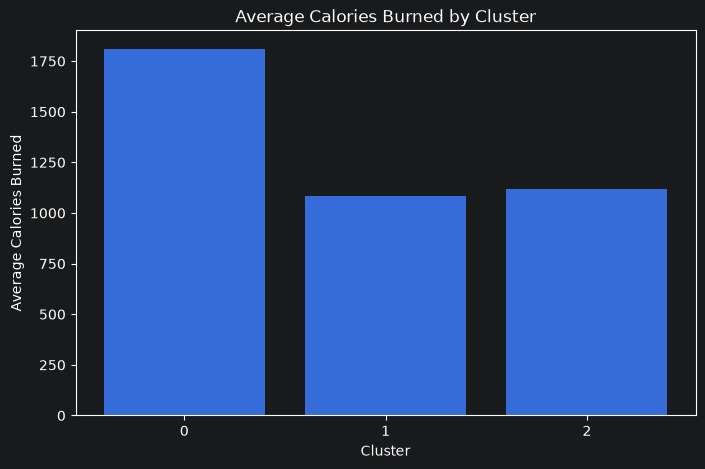

In [29]:
calories_by_cluster = df.groupby('Cluster')['Calories_Burned'].mean()
plt.figure(figsize=(8,5))

plt.bar(calories_by_cluster.index, calories_by_cluster.values)

plt.xlabel('Cluster')
plt.ylabel('Average Calories Burned')
plt.title('Average Calories Burned by Cluster')

plt.xticks([0, 1, 2])
plt.show()



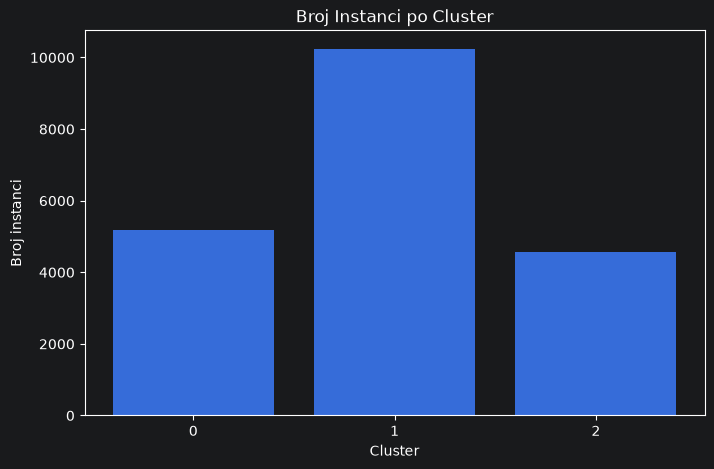

In [30]:
broj_klastera = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(broj_klastera.index, broj_klastera.values)

plt.xlabel('Cluster')
plt.ylabel('Broj instanci')
plt.title('Broj Instanci po Cluster')

plt.xticks([0, 1, 2])
plt.show()



In [31]:
df.groupby('Cluster')['Calories_Burned'].agg(['mean', 'std'])

,mean,std
Cluster,,
0,1810.490547,475.766207
1,1083.423795,354.838770
2,1117.896056,363.259514


U posmatranom skupu podataka, ispitanici iz Klastera 0 imaju prosečnu vrednost Calories_Burned od 1810,49, uz standardnu devijaciju od 475,77,dok u klaster 1 i 2 imaju mnogo manju prosecnu vrednost potrosnje kalorija (1083.423795,1117.896056) sa slicnom standardnom devjiacijom

In [32]:
#ANOVA test


from scipy.stats import f_oneway

anova_result = f_oneway(
    df[df['Cluster'] == 0]['Calories_Burned'],
    df[df['Cluster'] == 1]['Calories_Burned'],
    df[df['Cluster'] == 2]['Calories_Burned']
)

anova_result





F_onewayResult(statistic=np.float64(6446.3257965777), pvalue=np.float64(0.0))

In [33]:
#Postoji statisticki znacajna razlika izmedju potrosnje kalorije ovih klastera

In [34]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    df['Calories_Burned'],
    df['Cluster']
)

print(tukey_result)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
     0      1 -727.0668   0.0 -742.7031 -711.4304   True
     0      2 -692.5945   0.0 -711.2183 -673.9707   True
     1      2   34.4723   0.0   18.1356    50.809   True
--------------------------------------------------------


In [35]:
cluster_means = df.groupby('Cluster')[features.columns].mean()

cluster_means

,Age,Weight (kg),Height (m),Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Workout_Frequency (days/week),Experience_Level,Daily meals frequency,Proteins,Sets,Reps
Cluster,,,,,,,,,,,,,
0,38.140697,73.066669,1.733473,142.135460,62.024992,1.663055,25.626556,4.392553,2.750385,2.865539,100.039417,4.514440,20.064719
1,39.419146,60.822709,1.695014,144.288812,62.553074,1.108637,23.633869,2.932598,1.460041,2.840699,99.916714,4.381776,19.200638
2,38.386372,104.189781,1.774294,144.178030,61.588490,1.138554,32.178756,2.962748,1.521536,2.918063,99.783983,4.420473,19.210616


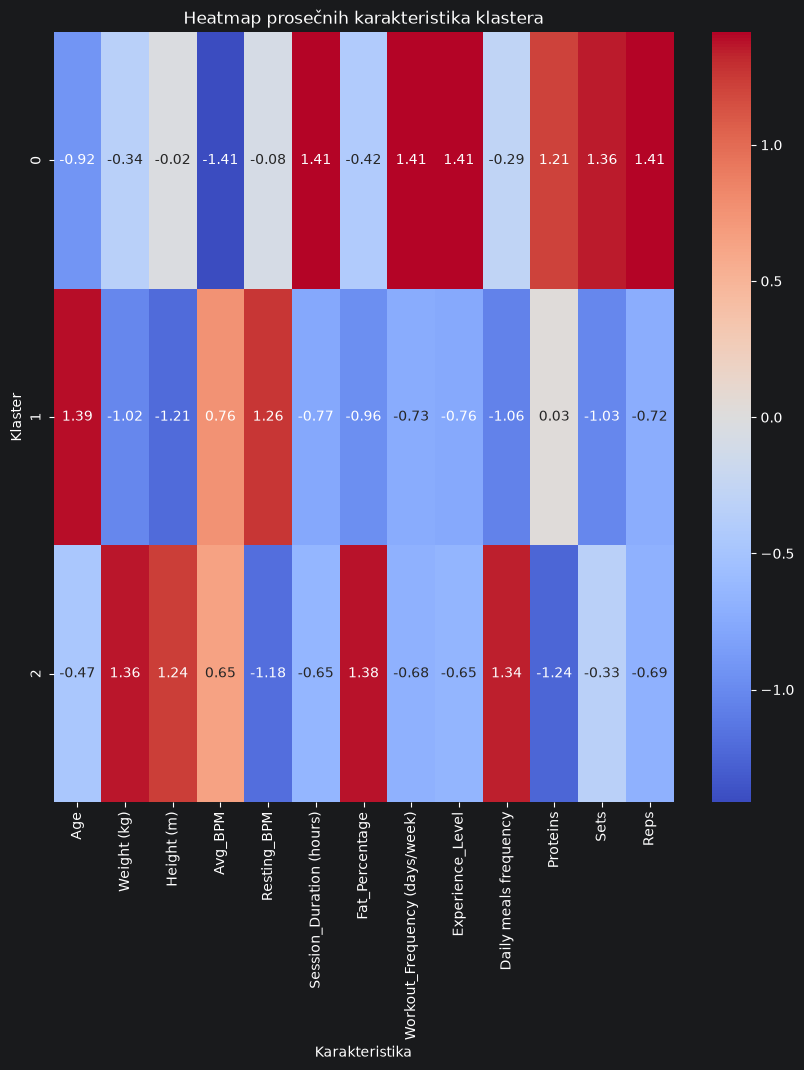

In [36]:
cluster_means = df.groupby('Cluster')[features.columns].mean()





cluster_means_scaled = StandardScaler().fit_transform(cluster_means)

cluster_means_scaled = pd.DataFrame(
    cluster_means_scaled,
    index=cluster_means.index,
    columns=cluster_means.columns
)

plt.figure(figsize=(10,10))
sb.heatmap(cluster_means_scaled,
           annot=True,
           cmap='coolwarm',
           fmt='.2f',
           center=0)

plt.title('Heatmap prosečnih karakteristika klastera')
plt.xlabel('Karakteristika')
plt.ylabel('Klaster')
plt.show()





In [37]:
cluster_profile = df.groupby('Cluster').agg(
    Broj_clanova=('Cluster', 'size'),
    Prosecne_kalorije=('Calories_Burned', 'mean'),
    Prosecna_tezina=('Weight (kg)', 'mean'),
    Procenat_masti=('Fat_Percentage', 'mean'),
    Trajanje_treninga=('Session_Duration (hours)', 'mean'),
    Ucestalost_treninga=('Workout_Frequency (days/week)', 'mean'),
    Iskustvo=('Experience_Level', 'mean')
)

cluster_profile

,Broj_clanova,Prosecne_kalorije,Prosecna_tezina,Procenat_masti,Trajanje_treninga,Ucestalost_treninga,Iskustvo
Cluster,,,,,,,
0,5194,1810.490547,73.066669,25.626556,1.663055,4.392553,2.750385
1,10242,1083.423795,60.822709,23.633869,1.108637,2.932598,1.460041
2,4564,1117.896056,104.189781,32.178756,1.138554,2.962748,1.521536


In [38]:
#HIJERARHIJSKA KLASTERIZACIJA

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)




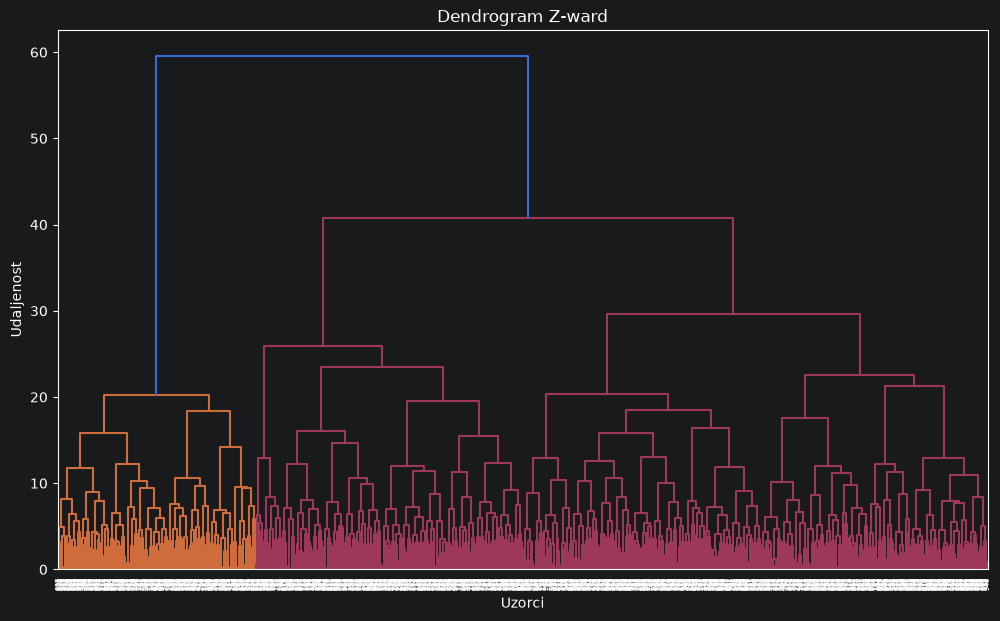

In [41]:
from scipy.cluster.hierarchy import dendrogram,linkage

sample = features_scaled[:1000]

#1. ward
Z_ward = linkage(sample, method='ward')

plt.figure(figsize=(12,7))
dendrogram(Z_ward)

plt.title('Dendrogram Z-ward')
plt.xlabel('Uzorci')
plt.ylabel('Udaljenost')
plt.show()






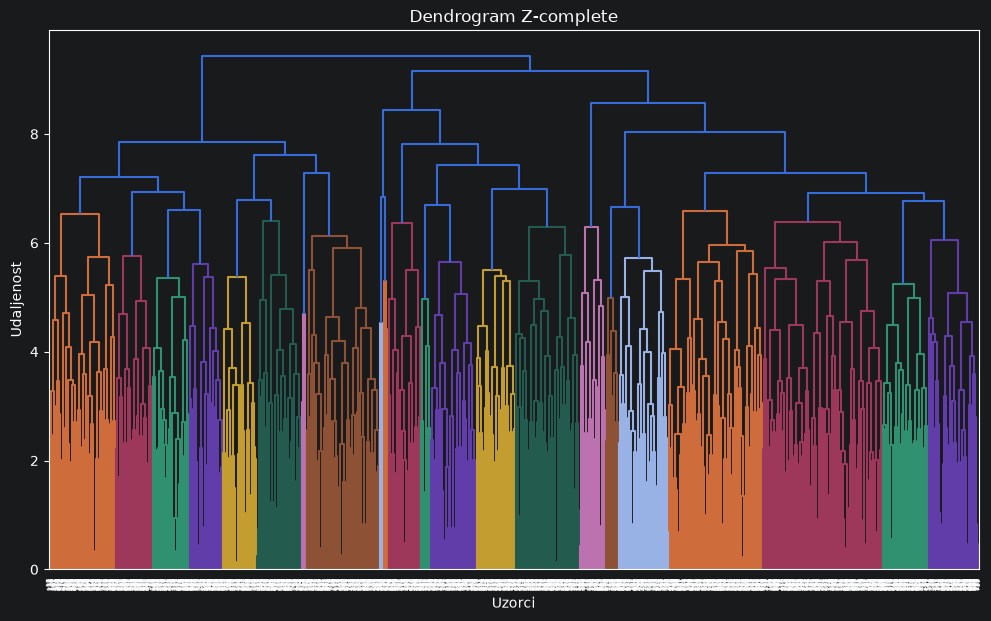

In [42]:
Z_complete = linkage(sample, method='complete')

plt.figure(figsize=(12,7))
dendrogram(Z_complete)

plt.title('Dendrogram Z-complete')
plt.xlabel('Uzorci')
plt.ylabel('Udaljenost')
plt.show()



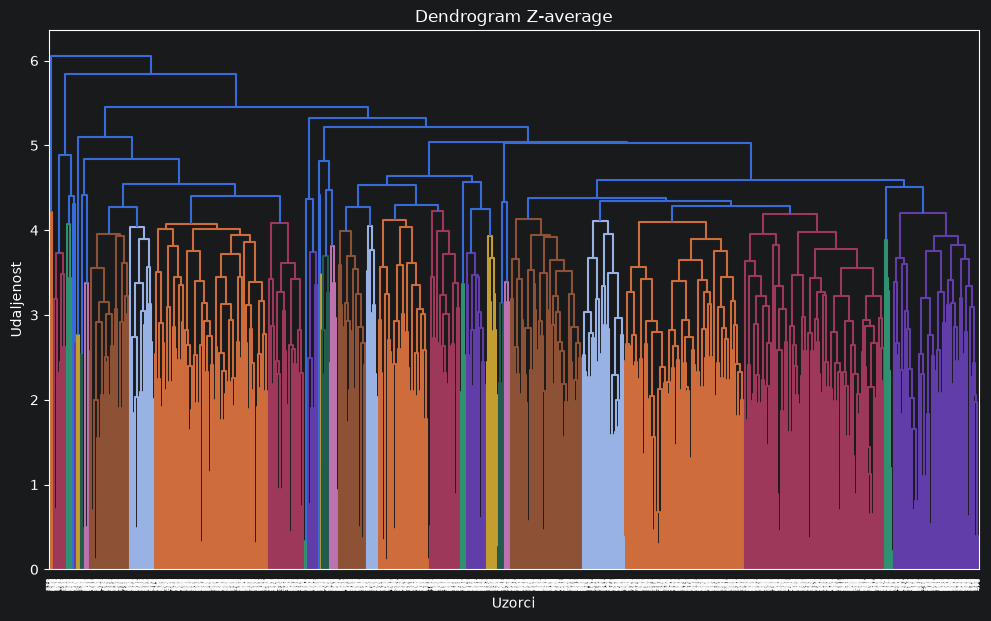

In [43]:
Z_average = linkage(sample, method='average')

plt.figure(figsize=(12,7))
dendrogram(Z_average)

plt.title('Dendrogram Z-average')
plt.xlabel('Uzorci')
plt.ylabel('Udaljenost')
plt.show()



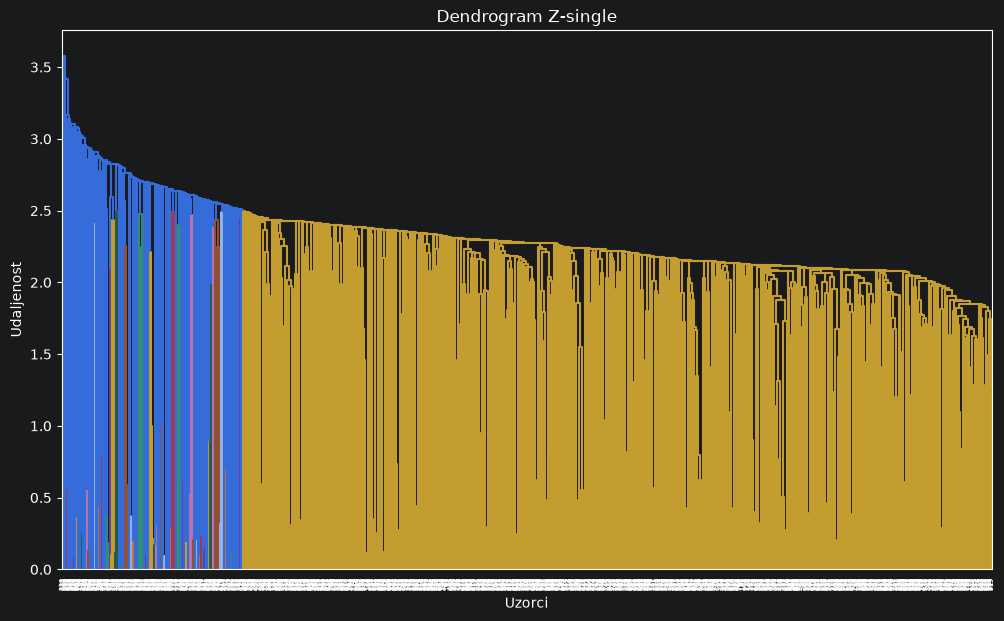

In [44]:
Z_single = linkage(sample, method='single')

plt.figure(figsize=(12,7))
dendrogram(Z_single)

plt.title('Dendrogram Z-single')
plt.xlabel('Uzorci')
plt.ylabel('Udaljenost')
plt.show()

In [46]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)

agg_labels = agg.fit_predict(features_scaled)



In [47]:
#silhouette scores

ward_scores=[]

for k in range(2,8):
    agg = AgglomerativeClustering(n_clusters=k,linkage='ward')
    labels = agg.fit_predict(features_scaled)

    score = silhouette_score(features_scaled, labels)
    ward_scores.append(score)

ward_scores





[0.13201895684315518,
 0.11237691010188018,
 0.06927018368025217,
 0.07373022848241258,
 0.06997326883467715,
 0.05042716272628145]

In [48]:
complete_scores = []

for k in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=k, linkage='complete')
    labels = agg.fit_predict(features_scaled)

    score = silhouette_score(features_scaled, labels)
    complete_scores.append(score)

complete_scores

[0.11891681614067165,
 0.1087494538973576,
 0.09095186158123181,
 0.07366986423769975,
 0.05468566263311827,
 0.030506281433119627,
 0.02965527097734585]

In [51]:
average_scores = []

for k in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=k, linkage='average')
    labels = agg.fit_predict(features_scaled)

    score = silhouette_score(features_scaled, labels)
    average_scores.append(score)

average_scores


[0.2126812043833246,
 0.13149333059442866,
 0.09207941302862953,
 0.10746586196018018,
 0.08675254188581955,
 0.07494072808542866,
 0.06241654029225873]

In [52]:
single_scores = []

for k in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=k, linkage='single')
    labels = agg.fit_predict(features_scaled)

    score = silhouette_score(features_scaled, labels)
    single_scores.append(score)

single_scores

[0.16932552450752375,
 0.11450646942367343,
 0.11235271410458077,
 0.0724570754324204,
 0.028393017123194482,
 0.021270532683243637,
 -0.003260531663419644]

In [55]:
#uzimamo single jer je najveci silhouete score za k=4
agg_single = AgglomerativeClustering(
    n_clusters=4,
    linkage='single',
)
agg_single_labels = agg_single.fit_predict(features_scaled)

In [56]:
df['Agglomerative_Cluster'] = agg_single_labels

In [57]:
agg_cluster_profile = df.groupby('Agglomerative_Cluster').agg(
    Broj_clanova=('Agglomerative_Cluster', 'size'),
    Prosecne_kalorije=('Calories_Burned', 'mean'),
    Prosecna_tezina=('Weight (kg)', 'mean'),
    Procenat_masti=('Fat_Percentage', 'mean'),
    Trajanje_treninga=('Session_Duration (hours)', 'mean'),
    Ucestalost_treninga=('Workout_Frequency (days/week)', 'mean'),
    Iskustvo=('Experience_Level', 'mean')
)

agg_cluster_profile

,Broj_clanova,Prosecne_kalorije,Prosecna_tezina,Procenat_masti,Trajanje_treninga,Ucestalost_treninga,Iskustvo
Agglomerative_Cluster,,,,,,,
0,19936,1280.379381,73.850049,26.100240,1.259769,3.318797,1.809655
1,22,1296.935909,108.177273,33.372941,1.270909,2.999545,1.007727
2,25,1271.228000,49.982800,16.147541,1.146000,3.003200,2.006400
3,17,955.022353,121.917059,32.587531,1.032941,3.997647,1.994706


In [62]:
agg_average = AgglomerativeClustering(
    n_clusters=4,
    linkage='average',
)
agg_average_labels = agg_single.fit_predict(features_scaled)


In [63]:
df['Agglomerative_Average_Cluster'] = agg_average_labels

In [64]:
agg_average_profile = df.groupby('Agglomerative_Average_Cluster').agg(
    Broj_clanova=('Agglomerative_Average_Cluster', 'size'),
    Prosecne_kalorije=('Calories_Burned', 'mean'),
    Prosecna_tezina=('Weight (kg)', 'mean'),
    Procenat_masti=('Fat_Percentage', 'mean'),
    Trajanje_treninga=('Session_Duration (hours)', 'mean'),
    Ucestalost_treninga=('Workout_Frequency (days/week)', 'mean'),
    Iskustvo=('Experience_Level', 'mean')
)

agg_average_profile

,Broj_clanova,Prosecne_kalorije,Prosecna_tezina,Procenat_masti,Trajanje_treninga,Ucestalost_treninga,Iskustvo
Agglomerative_Average_Cluster,,,,,,,
0,19936,1280.379381,73.850049,26.100240,1.259769,3.318797,1.809655
1,22,1296.935909,108.177273,33.372941,1.270909,2.999545,1.007727
2,25,1271.228000,49.982800,16.147541,1.146000,3.003200,2.006400
3,17,955.022353,121.917059,32.587531,1.032941,3.997647,1.994706


In [65]:
agg_ward = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

agg_ward_labels = agg_ward.fit_predict(features_scaled)

In [66]:
df['Agglomerative_Ward_Cluster'] = agg_ward_labels

In [67]:
agg_ward_profile = df.groupby('Agglomerative_Ward_Cluster').agg(
    Broj_clanova=('Agglomerative_Ward_Cluster', 'size'),
    Prosecne_kalorije=('Calories_Burned', 'mean'),
    Prosecna_tezina=('Weight (kg)', 'mean'),
    Procenat_masti=('Fat_Percentage', 'mean'),
    Trajanje_treninga=('Session_Duration (hours)', 'mean'),
    Ucestalost_treninga=('Workout_Frequency (days/week)', 'mean'),
    Iskustvo=('Experience_Level', 'mean')
)

agg_ward_profile

,Broj_clanova,Prosecne_kalorije,Prosecna_tezina,Procenat_masti,Trajanje_treninga,Ucestalost_treninga,Iskustvo
Agglomerative_Ward_Cluster,,,,,,,
0,7545,1036.751429,66.415258,25.612977,1.076425,2.779927,1.331608
1,5310,1276.265557,62.023422,23.124837,1.257213,3.450036,1.857887
2,3154,1099.289705,109.215869,32.475497,1.121176,2.933668,1.488221
3,3991,1888.191591,75.936429,25.947321,1.717692,4.466434,2.900857


In [ ]:
7545,1036.751429,66.415258,25.612977,1.076425,2.779927,1.331608
5310,1276.265557,62.023422,23.124837,1.257213,3.450036,1.857887
3154,1099.289705,109.215869,32.475497,1.121176,2.933668,1.488221
3991,1888.191591,75.936429,25.947321,1.717692,4.466434,2.900857
